In [22]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

In [23]:
def plot_multistage_cic_fir_frequency_response(
    R1=16, M=1, N=4,         # CIC parameters
    R2=16, num_taps=63,      # FIR parameters
    fs_in=12500000.0         # Input rate to Stage 1
):
    """
    Plots combined frequency response for Stage 1 (CIC) + Stage 2 (FIR).
    
    Decimation path:
    fs_in ---> [ Stage 1: CIC (R1) ] ---> fs_stage2 (fs_in / R1)
           ---> [ Stage 2: FIR (R2) ] ---> fs_out (fs_in / (R1 * R2))
    """
    # Sampling Rates
    fs_stage2 = fs_in / R1
    fs_out = fs_stage2 / R2
    R_total = R1 * R2
    
    nyq_out = fs_out / 2.0
    dc_gain_cic = (R1 * M) ** N
    
    # -------------------------------------------------------------------------
    # 1. Design Stage 2 FIR Filter Taps (at fs_stage2 rate)
    # -------------------------------------------------------------------------
    cutoff_freq = nyq_out  # Target cutoff at final output Nyquist
    taps = signal.firwin(num_taps, cutoff_freq, fs=fs_stage2, window=('kaiser', 5.0))
    n_taps = np.arange(len(taps))

    # -------------------------------------------------------------------------
    # 2. Pre-Decimation Full-Band Frequency Response (0 to fs_in / 2)
    # -------------------------------------------------------------------------
    f_in = np.linspace(1e-5, fs_in / 2, 8000)
    omega_in = 2 * np.pi * f_in / fs_in
    
    # A. Stage 1 CIC Transfer Function
    num_cic = 1 - np.exp(-1j * omega_in * R1 * M)
    den_cic = 1 - np.exp(-1j * omega_in)
    H_cic_in = np.where(np.abs(den_cic) < 1e-12, dc_gain_cic, num_cic / den_cic) ** N
    H_cic_in_norm = H_cic_in / dc_gain_cic
    
    # B. Stage 2 FIR Transfer Function evaluated on fs_in grid
    omega_stage2_grid = 2 * np.pi * f_in / fs_stage2
    H_fir_in = np.dot(np.exp(-1j * np.outer(omega_stage2_grid, n_taps)), taps)
    
    # C. Combined Pre-Decimation Response
    H_combined_in = H_cic_in_norm * H_fir_in
    mag_combined_in_db = 20 * np.log10(np.abs(H_combined_in) + 1e-12)

    # -------------------------------------------------------------------------
    # 3. Post-Decimation Folded Baseband Spectrum (0 to fs_out / 2)
    # -------------------------------------------------------------------------
    f_out = np.linspace(1e-5, nyq_out, 2000)
    H_folded = np.zeros(len(f_out), dtype=complex)
    
    # Fold all R_total aliases back into the baseband
    for k in range(R_total):
        f_shifted = f_out + (k * fs_out)
        omega_k_in = 2 * np.pi * f_shifted / fs_in
        omega_k_stage2 = 2 * np.pi * f_shifted / fs_stage2
        
        # Stage 1 CIC component
        num_k = 1 - np.exp(-1j * omega_k_in * R1 * M)
        den_k = 1 - np.exp(-1j * omega_k_in)
        H_cic_k = np.where(np.abs(den_k) < 1e-12, dc_gain_cic, num_k / den_k) ** N
        H_cic_k_norm = H_cic_k / dc_gain_cic
        
        # Stage 2 FIR component
        H_fir_k = np.dot(np.exp(-1j * np.outer(omega_k_stage2, n_taps)), taps)
        
        # Accumulate folded response
        H_folded += (H_cic_k_norm * H_fir_k)
        
    H_folded = H_folded / R_total
    mag_folded_db = 20 * np.log10(np.abs(H_folded) + 1e-12)

    # -------------------------------------------------------------------------
    # 4. Plotting
    # -------------------------------------------------------------------------
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8))
    
    # Subplot 1: Pre-Decimation Cascade
    ax1.plot(f_in, 20 * np.log10(np.abs(H_cic_in_norm) + 1e-12), '--', color='gray', alpha=0.6, label='Stage 1 CIC Only')
    ax1.plot(f_in, mag_combined_in_db, color='blue', linewidth=2, label=f'Cascaded CIC+FIR (R1={R1}, R2={R2})')
    ax1.axvline(nyq_out, color='red', linestyle='--', label=f'Final Output Nyquist ({nyq_out:.1f} Hz)')
    
    # Mark Stage 2 sampling rate multiples and alias zones
    for i in range(1, int(R_total / 2) + 1):
        null_freq = i * fs_out
        if null_freq < fs_in / 2:
            ax1.axvline(null_freq, color='green', linestyle=':', alpha=0.4)
            ax1.axvspan(null_freq - nyq_out, min(null_freq + nyq_out, fs_in / 2), 
                        color='gray', alpha=0.08, label='Aliasing Zone' if i == 1 else "")

    ax1.set_title(f'1. Pre-Decimation Cascaded Response (Input Rate: {fs_in:.2f} Hz)')
    ax1.set_xlabel('Frequency (Hz)')
    ax1.set_ylabel('Magnitude (dB)')
    ax1.set_ylim([-120, 5])
    ax1.set_xlim([0, 0.4e6])
    ax1.grid(True, linestyle='-', alpha=0.4)
    ax1.legend(loc='upper right')

    # Subplot 2: Post-Decimation Composite Spectrum
    ax2.plot(f_out, mag_folded_db, color='purple', linewidth=2, 
             label=f'Cascaded Baseband Spectrum (fs_out = {fs_out:.2f} Hz)')
    ax2.set_title('2. Post-Decimation Composite Baseband Spectrum (Includes All Alias Folding)')
    ax2.set_xlabel('Baseband Frequency (Hz)')
    ax2.set_ylabel('Magnitude (dB)')
    ax2.set_ylim([-120, 5])
    ax2.set_xlim([0, nyq_out])
    ax2.grid(True, linestyle='-', alpha=0.4)
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()



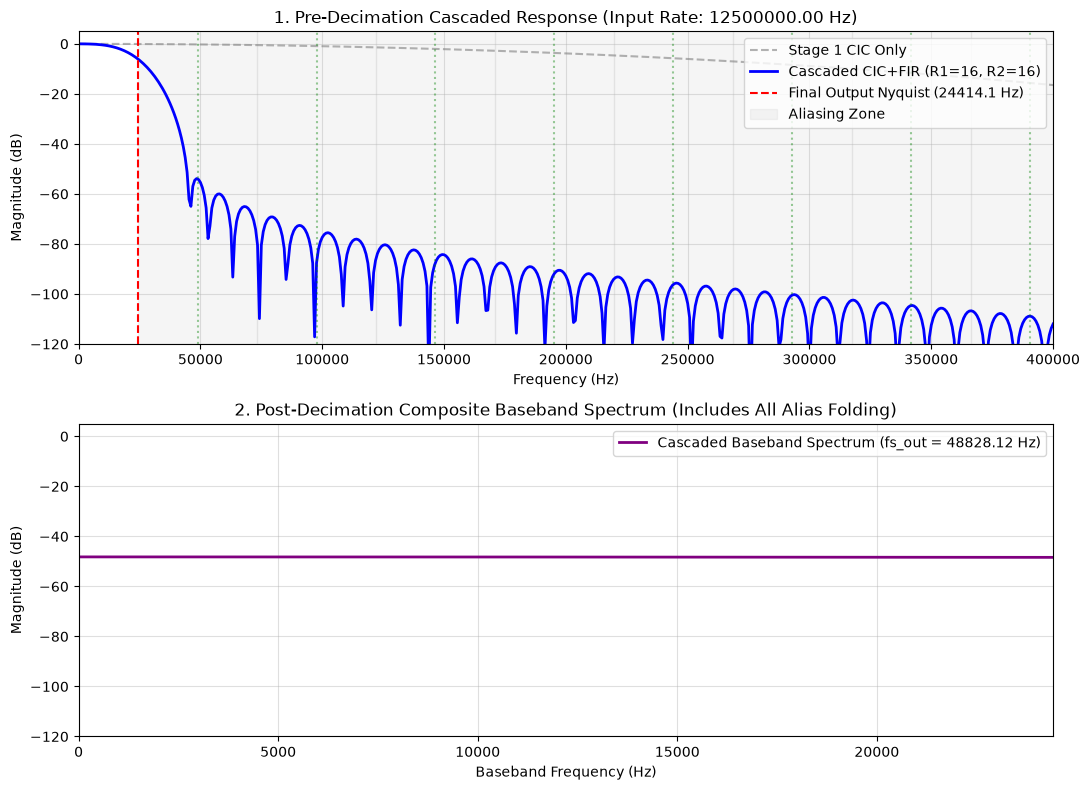

In [24]:
plot_multistage_cic_fir_frequency_response(R1=16, M=1, N=4, R2=16, num_taps=63, fs_in=12500000.0)

In [25]:
def design_halfband_fir(num_taps=31):
    """
    Designs a Type-1 Linear Phase Half-Band FIR filter.
    Ensures num_taps is odd (4k+3 or 4k+1) so every even-indexed tap 
    (except center) is forced to EXACTLY 0.
    """
    if num_taps % 2 == 0:
        num_taps += 1  # Half-band filters must have odd length
        
    # Cutoff at fs/4 (0.25 normalized)
    taps = signal.firwin(num_taps, 0.25, window=('kaiser', 5.0), fs=1.0)
    
    # Enforce strict zero-taps for half-band symmetry
    center = num_taps // 2
    for i in range(num_taps):
        if (i - center) % 2 == 0 and i != center:
            taps[i] = 0.0
            
    # Force center tap to exactly 0.5 for ideal 6 dB passband gain
    taps[center] = 0.5
    return taps

In [28]:
def plot_cic_with_4_halfband_cascade(
    R1=16, M=1, N_cic=4,      # Stage 1 CIC
    hb_taps_count=31,         # Taps per Half-Band stage
    fs_in=12500000.0,         # High input rate (12.5 MHz)
    f_max_plot=1e6            # View limit (1 MHz)
):
    """
    Cascades Stage 1 CIC (R1=16) with 4 Half-Band FIR Stages (R2_total = 2^4 = 16)
    Total Decimation R_total = 16 * 16 = 256
    """
    # -------------------------------------------------------------------------
    # 1. Setup Sampling Rates across the 5 total stages
    # -------------------------------------------------------------------------
    fs_stage1_out = fs_in / R1                    # 781.25 kHz
    fs_hb1_out = fs_stage1_out / 2                 # 390.625 kHz
    fs_hb2_out = fs_hb1_out / 2                    # 195.3125 kHz
    fs_hb3_out = fs_hb2_out / 2                    # 97.65625 kHz
    fs_hb4_out = fs_hb3_out / 2                    # 48.828125 kHz (Final Rate)
    
    nyq_final = fs_hb4_out / 2.0                   # 24.414 kHz
    
    # Design base Half-Band Taps
    hb_taps = design_halfband_fir(hb_taps_count)
    n_hb = np.arange(len(hb_taps))
    
    # -------------------------------------------------------------------------
    # 2. Evaluate Frequency Grid (0 to fs_in / 2)
    # -------------------------------------------------------------------------
    f_grid = np.linspace(1e-5, f_max_plot, 8000)
    
    # A. Stage 1: CIC Response
    omega_in = 2 * np.pi * f_grid / fs_in
    dc_gain_cic = (R1 * M) ** N_cic
    num_cic = 1 - np.exp(-1j * omega_in * R1 * M)
    den_cic = 1 - np.exp(-1j * omega_in)
    H_cic = np.where(np.abs(den_cic) < 1e-12, dc_gain_cic, num_cic / den_cic) ** N_cic
    H_cic_norm = H_cic / dc_gain_cic

    # B. Stage 2: 4 Half-Band FIR Stages in Series
    # HB1 runs at fs_stage1_out
    omega_hb1 = 2 * np.pi * f_grid / fs_stage1_out
    H_hb1 = np.dot(np.exp(-1j * np.outer(omega_hb1, n_hb)), hb_taps)
    
    # HB2 runs at fs_hb1_out
    omega_hb2 = 2 * np.pi * f_grid / fs_hb1_out
    H_hb2 = np.dot(np.exp(-1j * np.outer(omega_hb2, n_hb)), hb_taps)
    
    # HB3 runs at fs_hb2_out
    omega_hb3 = 2 * np.pi * f_grid / fs_hb2_out
    H_hb3 = np.dot(np.exp(-1j * np.outer(omega_hb3, n_hb)), hb_taps)
    
    # HB4 runs at fs_hb3_out
    omega_hb4 = 2 * np.pi * f_grid / fs_hb3_out
    H_hb4 = np.dot(np.exp(-1j * np.outer(omega_hb4, n_hb)), hb_taps)

    # C. Cascaded Combined Transfer Function
    H_hb_cascade = H_hb1 * H_hb2 * H_hb3 * H_hb4
    H_total = H_cic_norm * H_hb_cascade
    
    # Magnitude conversions
    mag_cic_db = 20 * np.log10(np.abs(H_cic_norm) + 1e-12)
    mag_hb_db = 20 * np.log10(np.abs(H_hb_cascade) + 1e-12)
    mag_total_db = 20 * np.log10(np.abs(H_total) + 1e-12)

    # -------------------------------------------------------------------------
    # 3. Plotting
    # -------------------------------------------------------------------------
    plt.figure(figsize=(11, 6))
    
    plt.plot(f_grid, mag_cic_db, '--', color='gray', alpha=0.5, label='Stage 1: CIC Only')
    plt.plot(f_grid, mag_hb_db, ':', color='orange', linewidth=1.5, label='Stage 2: 4x Half-Band Cascade Only')
    plt.plot(f_grid, mag_total_db, color='blue', linewidth=2, label='Total Composite (CIC + 4x HB FIR)')
    
    plt.axvline(nyq_final, color='red', linestyle='--', label=f'Final Nyquist Limit ({nyq_final/1e3:.2f} kHz)')

    # Add harmonic marker lines for the final output sampling rate
    max_k = int(f_max_plot / fs_hb4_out) + 1
    first_green = True
    for i in range(1, max_k):
        null_freq = i * fs_hb4_out
        if null_freq <= f_max_plot:
            plt.axvline(null_freq, color='green', linestyle=':', alpha=0.3, 
                        label='Alias Center Markers' if first_green else "")
            first_green = False

    plt.title(f'Multi-Stage Decimation: CIC (R1=16) + 4x Half-Band FIR (2^4=16)\nTotal Decimation R = 256 | Input: {fs_in/1e6:.1f} MHz -> Output: {fs_hb4_out/1e3:.2f} kHz')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude (dB)')
    plt.ylim([-120, 5])
    plt.xlim([0, 0.1e6])
    plt.grid(True, linestyle='-', alpha=0.4)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    # Print out zero-tap confirmation
    print(f"Generated Half-Band Filter Taps ({len(hb_taps)} Taps total):")
    print(np.round(hb_taps, 4))
    print(f"\nZero-value Taps count: {np.sum(hb_taps == 0)} out of {len(hb_taps)} taps (Saving ~50% multipliers!)")

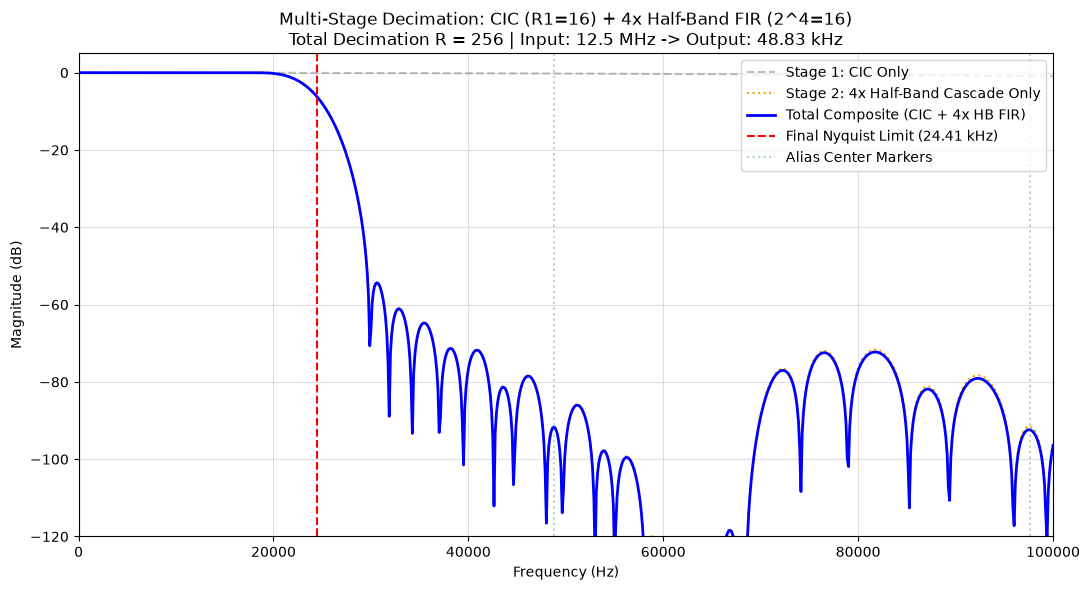

Generated Half-Band Filter Taps (31 Taps total):
[-0.0008  0.      0.0029  0.     -0.0072  0.      0.0147  0.     -0.0273
  0.      0.0494  0.     -0.097   0.      0.3152  0.5     0.3152  0.
 -0.097   0.      0.0494  0.     -0.0273  0.      0.0147  0.     -0.0072
  0.      0.0029  0.     -0.0008]

Zero-value Taps count: 14 out of 31 taps (Saving ~50% multipliers!)


In [29]:
plot_cic_with_4_halfband_cascade(R1=16, M=1, N_cic=4, hb_taps_count=31, fs_in=12500000.0, f_max_plot=1e6)